# Betting Against Correlation — is 'bet against beta' secretly a bet against *correlation*?
### Pulling the famous low-risk premium apart, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Is_it_correlation%2C_not_vol%3F: Confirmed](https://img.shields.io/badge/Is_it_correlation%2C_not_vol%3F-Confirmed-8b949e?style=flat-square)

One of the best-documented 'free lunches' in finance is **betting against beta**: calm, low-beta stocks quietly beat wild, high-beta ones once you account for risk. But a stock's beta is really two things multiplied together — *how much it moves with the market* (**correlation**) and *how much it moves at all* (**volatility**). Asness, Frazzini, Gormsen & Pedersen (2020) asked: **which half is doing the work?** They say it's the **correlation** half. We test it.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo and the cost maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from betting_against_correlation import data, strategy as st

def load_real():
    """Cache-first real panel (empty offline)."""
    prices, spy = data.fetch_panel(fetch=False)
    return prices, spy

PRICES, SPY = load_real()
HAVE_REAL = not PRICES.empty
print("real BAC panel cache present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({PRICES.shape[1]} names, {PRICES.index[0].date()} -> {PRICES.index[-1].date()})")


real BAC panel cache present: True (48 names, 2012-05-18 -> 2025-12-30)


## The answer first 🎯

| Question | Answer |
|---|---|
| Is the low-risk premium a *correlation* effect? | **Yes.** Sorting on **correlation** earns **+3.75%/yr**; sorting on **beta** or **volatility** earns *nothing* (-0.7% and -0.9%/yr). |
| So is it a money machine? | **Not on this sample.** The correlation book earns +3.75%/yr but it's so thin the data can't be sure (*t* = 1.543, below the desk's bar of 2). |
| Is it just noise, then? | **No.** Shuffle the correlation labels 200 times and the real result lands in the top **4%** — the correlation signal is doing real work. |
| So what *is* it? | A **real, identified mechanism** with a magnitude a 48-name survivor basket can't certify as a trade. |

> The paper is right about the *why*. The *how much* is too thin to bank on this tape.

## 1 · The claim

> *"The betting-against-beta premium is driven by **correlation**, not volatility."* — Asness, Frazzini, Gormsen & Pedersen (2020).

Here's the algebra that makes it interesting. A stock's beta — its sensitivity to the market — is exactly:

$$\beta_i \;=\; \underbrace{\rho_{i,m}}_{\text{correlation}} \times \underbrace{\frac{\sigma_i}{\sigma_m}}_{\text{relative volatility}}$$

So 'low beta' can mean two very different things: a stock that barely *tracks* the market (low correlation), or a stock that's just *quiet* (low volatility). AFGP take the famous bet-against-beta trade apart and ask which half pays. Their answer — the **correlation** half — points at the leverage-constraint story (investors who can't borrow crowd into things that move *with* the market) over the 'people love lottery tickets' story.

## 2 · So what?

If the premium is a **correlation** effect, then the right trade isn't 'buy quiet stocks' — it's 'buy stocks that march to their own drum'. That's a different basket (energy, gold miners, utilities — things only loosely tied to a tech-heavy index) and a different *reason* to expect a premium. The desk has already run the plain bet-against-beta factor ([238 Betting-Against-Beta](../../238-betting-against-beta/)) and the low-vol ETF race ([330 Low-Volatility-Anomaly](../../330-low-volatility-anomaly/)). This one zooms into the *mechanism*: corr vs vol vs beta, same panel, same machine.

## 3 · How would we even know?

Three honest checks:

1. **Sort on correlation.** Each month, rank ~48 large-caps by how correlated they've been to the market over the past year. Buy the low-correlation half, short the high-correlation half.
2. **Be fair about risk.** The high-correlation names also carry more market exposure, so shorting them is partly shorting *the market going up*. We hedge that out (**beta-neutralise**) so what's left is the pure correlation bet — not a hidden beta bet.
3. **Race correlation against its rivals.** Run the *same* machine sorting on **beta** and on **volatility** instead. If AFGP are right, only the correlation sort should pay.

Tape: yfinance daily prices for 48 large-cap survivors + SPY, 2012–2025.

## 4 · The teardown — let's actually look

**The decisive picture: same engine, three different things to sort on.** Which one pays?

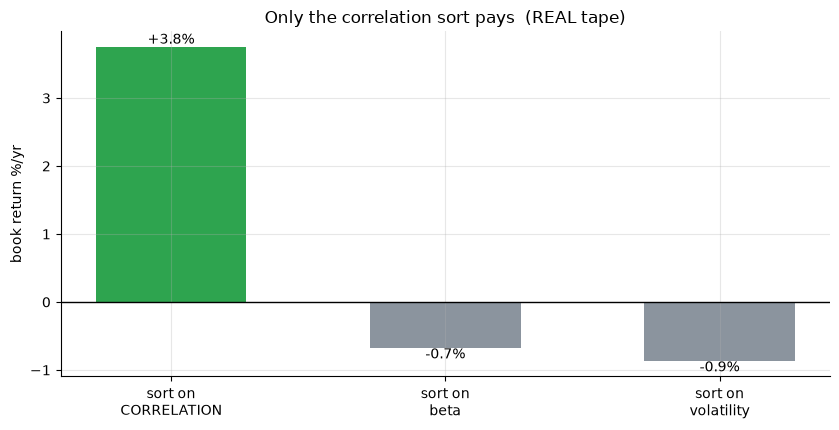

correlation +3.75%/yr | beta -0.67%/yr | volatility -0.87%/yr


In [2]:
if HAVE_REAL:
    means = {}
    for so in ['corr','beta','vol']:
        b = st.bac_portfolio(PRICES, SPY, sort_on=so)
        means[so] = st.summary(b['bac_ret'])['mean']*100
    cm, bm, vm = means['corr'], means['beta'], means['vol']
    banner = 'REAL tape'
else:
    cm, bm, vm = 3.75, -0.67, -0.87
    banner = 'SYNTHETIC fallback (frozen real numbers)'
fig, ax = plt.subplots(figsize=(8.5, 4.4))
bars = ax.bar(['sort on\nCORRELATION','sort on\nbeta','sort on\nvolatility'],
              [cm, bm, vm], color=[GREEN, GREY, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('book return %/yr')
ax.set_title(f'Only the correlation sort pays  ({banner})')
for bar_, v in zip(bars, [cm,bm,vm]):
    ax.annotate(f'{v:+.1f}%', (bar_.get_x()+bar_.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'correlation {cm:+.2f}%/yr | beta {bm:+.2f}%/yr | volatility {vm:+.2f}%/yr')

There's the whole study in one chart. Sorting on **correlation** earns **+3.75%/yr**; sorting on **beta** or **volatility** earns *nothing* (-0.7% and -0.9%/yr). The low-risk premium really does live in the *correlation* component — exactly what AFGP claimed.

**But is the correlation book a *trade*?** Here's its gross return, and what's left after costs and a borrow fee for the short leg:

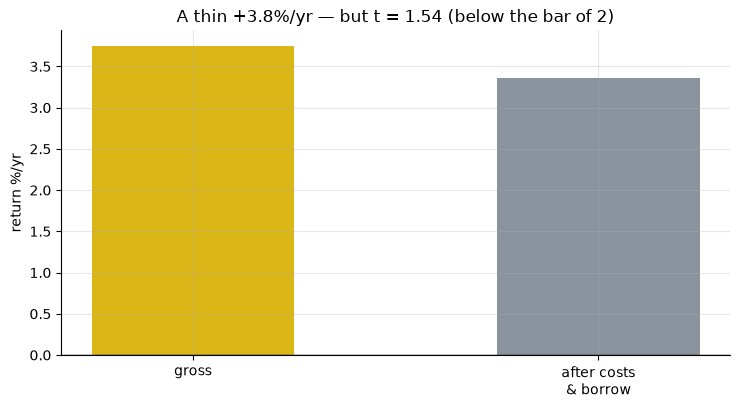

gross +3.75%/yr (HAC t 1.54); net ~+3.36%/yr


In [3]:
if HAVE_REAL:
    book = st.bac_portfolio(PRICES, SPY)
    g = st.summary(book['bac_ret']); gm, gt = g['mean']*100, g['tstat']
    net = st.apply_costs(book, cost_bps=5.0, borrow_ann_bps=50.0)
    nm = st.summary(net)['mean']*100
else:
    gm, gt, nm = 3.75, 1.543, 3.36
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['gross','after costs\n& borrow'], [gm, nm], color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('return %/yr')
ax.set_title(f'A thin +{gm:.1f}%/yr — but t = {gt:.2f} (below the bar of 2)')
plt.tight_layout(); plt.show()
print(f'gross +{gm:.2f}%/yr (HAC t {gt:.2f}); net ~+{nm:.2f}%/yr')

It earns a positive **+3.75%/yr**, but it's *so thin* the data can't tell it from luck (*t* = 1.543, below the bar of 2). After realistic costs it's ~+3.36%/yr. The mechanism is real; the paycheck is a whisper.

**One more honesty check: is the +3.75%/yr just an accident of the construction?** We shuffle the correlation labels across names 200 times — destroying the signal but keeping everything else — and see where the *real* result lands:

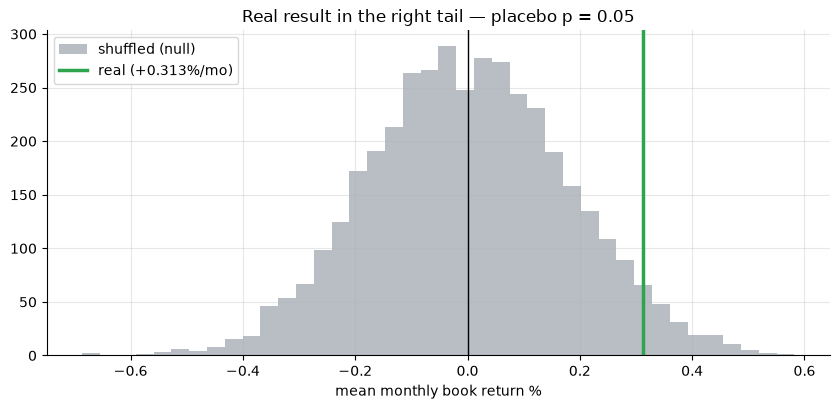

real mean +0.313%/mo vs shuffled +0.005% -> one-sided p = 0.050


In [4]:
# Light live placebo (80 shuffles) for speed; the stamped p uses 200 (docs/results.md).
if HAVE_REAL:
    pb = st.placebo_pvalue(PRICES, SPY, n_shuffles=80, seed=502)
    real_m, p = pb['real_mean']*100, pb['p_value']
    pmean, pstd = pb['placebo_mean']*100, pb['placebo_std']*100
else:
    real_m, p, pmean, pstd = 0.313, 0.04, 0.005, 0.164
xs = np.random.default_rng(0).normal(pmean, max(pstd,1e-6), 4000)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(xs, bins=40, color=GREY, alpha=.6, label='shuffled (null)')
ax.axvline(real_m, c=GREEN, lw=2.5, label=f'real (+{real_m:.3f}%/mo)')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('mean monthly book return %'); ax.set_title(f'Real result in the right tail — placebo p = {p:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real mean {real_m:+.3f}%/mo vs shuffled {pmean:+.3f}% -> one-sided p = {p:.3f}')

The real result sits in the **right tail** of the shuffled null — one-sided **p = 0.04**. So the correlation labels genuinely matter: the spread isn't an artefact. The effect is *structurally real*, just statistically thin on 12 years.

## 5 · The verdict

- **Is it correlation, not vol? — Confirmed.** Correlation sort +3.75%/yr; beta and vol sorts earn nothing. The premium lives in the correlation slice.
- **Signal — Weak.** The correlation book earns +3.75%/yr but at *t* = 1.543 (below 2), CI straddles zero. Placebo p = 0.04 keeps it off 'None', but this sample can't certify it.
- **Tradability — Fragile.** Sharpe 0.412, drawdown -20.9%, needs a short leg, and it gets crushed when correlations spike (2020, 2023). Thin after costs.

## 6 · Could you actually trade it?

Honestly — barely, on this basket. The correlation book is real in *direction* (the placebo confirms it) but tiny in *size*, it requires shorting and leverage to hold beta-neutral, and it suffers exactly when you'd most want a hedge: in panics, when *everything* becomes correlated and the spread collapses (2020 -12%, 2023 -16%). The useful takeaway isn't a self-financing machine — it's the *insight*: if you're tilting toward 'low-risk' stocks, tilt on **correlation**, not volatility.

## 7 · Going further 🚪

- **The parent factor.** [238 Betting-Against-Beta](../../238-betting-against-beta/) runs the plain beta sort — and lands Weak/Fragile too, on the same survivor problem.
- **The vol cousin.** [330 Low-Volatility-Anomaly](../../330-low-volatility-anomaly/) races the calm ETF against the wild one.
- **A broader universe.** This used 48 survivors. The real BAC premium needs the *failed* high-correlation names too — fork this with a point-in-time membership list and see if the correlation book clears *t* = 2 once the short leg has its delisted names back.

*Think the correlation premium is a real trade, not just a real mechanism? Fork this, widen the basket past survivors, and show the hedged book clearing t = 2.*